In [1]:
!pip install transformers fairlearn aif360 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 20.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, MetricFrame
import numpy as np

In [3]:
df = pd.read_csv('/content/drive/MyDrive/dreaddit_train_cleaned.csv')

In [4]:
age_group_mapping = {
    "13-17": 0,
    "18-24": 1,
    "25-34": 2,
    "35-49": 3,
    "50+": 4,
    "unknown": -1
}
df['age_label'] = df['age_group'].map(age_group_mapping)

In [5]:
df['gender_binary'] = df['gender'].apply(lambda x: 1 if str(x).lower() in ['male', 'm'] else 0)

In [6]:
df = df.dropna(subset=['text', 'label', 'age_label'])
df = df[df['age_label'] != -1]

In [7]:
X_train, X_test, y_train, y_test, a_train, a_test, g_train, g_test = train_test_split(
    df['text'], df['label'], df['age_label'], df['gender_binary'],
    test_size=0.2, random_state=42, stratify=df['label']
)

X_val, X_test, y_val, y_test, a_val, a_test, g_val, g_test = train_test_split(
    X_test, y_test, a_test, g_test,
    test_size=0.5, random_state=42, stratify=y_test
)

In [8]:
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, age_labels, gender_labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.ages = age_labels
        self.genders = gender_labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels.iloc[idx], dtype=torch.long),
            'age': torch.tensor(self.ages.iloc[idx], dtype=torch.long),
            'gender': torch.tensor(self.genders.iloc[idx], dtype=torch.long)
        }

In [9]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

batch_size = 8
train_dataset = MentalHealthDataset(X_train, y_train, a_train, g_train, tokenizer)
val_dataset = MentalHealthDataset(X_val, y_val, a_val, g_val, tokenizer)
test_dataset = MentalHealthDataset(X_test, y_test, a_test, g_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [10]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_, None

class GradientReversal(torch.nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)

In [11]:
class Adversary(nn.Module):
    def __init__(self, input_dim=768, output_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [12]:
def train_model_with_adversarial_debiasing(train_loader, val_loader, lambda_adv=0.1, epochs=3, learning_rate=2e-5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🚀 Training on: {device}")

    main_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2).to(device)
    adversary = Adversary(output_dim=5).to(device)
    grl = GradientReversal(lambda_=lambda_adv)

    optimizer_main = AdamW(main_model.parameters(), lr=learning_rate)
    optimizer_adv = AdamW(adversary.parameters(), lr=1e-4)

    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        main_model.train()
        adversary.train()
        total_loss = 0

        for batch_idx, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            sensitive_labels = batch['age'].to(device)

            optimizer_main.zero_grad()
            optimizer_adv.zero_grad()

            outputs = main_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            classification_loss = outputs.loss

            hidden = main_model.roberta(input_ids=input_ids, attention_mask=attention_mask)[0][:, 0, :]
            reversed_hidden = grl(hidden)
            adv_preds = adversary(reversed_hidden)
            adv_loss = loss_fn(adv_preds, sensitive_labels)

            total_loss_combined = classification_loss + lambda_adv * adv_loss
            total_loss_combined.backward()

            torch.nn.utils.clip_grad_norm_(main_model.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(adversary.parameters(), 1.0)

            optimizer_main.step()
            optimizer_adv.step()

            total_loss += total_loss_combined.item()

        print(f"Epoch {epoch+1} finished. Avg loss: {total_loss/len(train_loader):.4f}")
        print("-"*50)

    return main_model

In [13]:
model = train_model_with_adversarial_debiasing(train_loader, val_loader)

🚀 Training on: cuda


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1 finished. Avg loss: 0.6858
--------------------------------------------------
Epoch 2 finished. Avg loss: 0.5522
--------------------------------------------------
Epoch 3 finished. Avg loss: 0.4622
--------------------------------------------------


In [14]:
def evaluate(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            outputs = model(**inputs)
            _, preds = torch.max(outputs.logits, 1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch['label'].cpu().numpy())

    print(classification_report(true_labels, predictions, digits=4))

In [15]:
evaluate(model, test_loader)

              precision    recall  f1-score   support

           0     0.8987    0.6396    0.7474       111
           1     0.7436    0.9355    0.8286       124

    accuracy                         0.7957       235
   macro avg     0.8212    0.7876    0.7880       235
weighted avg     0.8169    0.7957    0.7902       235



In [16]:
def evaluate_fairness(model, test_loader, y_test, g_test, a_test):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    y_pred = []
    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            outputs = model(**inputs)
            _, preds = torch.max(outputs.logits, 1)
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_test)
    y_pred = np.array(y_pred)

    dpd_gender = demographic_parity_difference(y_true, y_pred, sensitive_features=np.array(g_test))
    dpd_age = demographic_parity_difference(y_true, y_pred, sensitive_features=np.array(a_test))

    print(f"\n📊 Demographic Parity Difference (Gender): {dpd_gender:.4f}")
    print(f"📊 Demographic Parity Difference (Age Group): {dpd_age:.4f}")

    # Plot
    plt.figure(figsize=(6, 4))
    sns.barplot(x=['Gender', 'Age Group'], y=[dpd_gender, dpd_age], palette='pastel')
    plt.title('Demographic Parity Difference')
    plt.ylabel('DPD Value')
    plt.ylim(0, 1)
    plt.axhline(0.1, color='red', linestyle='--', label='Acceptable Threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()


📊 Demographic Parity Difference (Gender): 0.1663
📊 Demographic Parity Difference (Age Group): 0.0864


<ipython-input-16-8d7116e4a439>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Gender', 'Age Group'], y=[dpd_gender, dpd_age], palette='pastel')


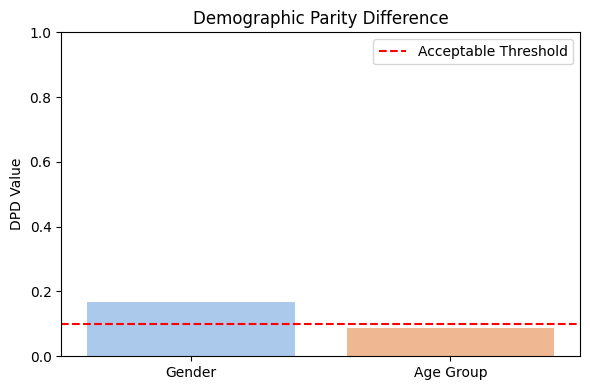

In [17]:
evaluate_fairness(model, test_loader, y_test, g_test, a_test)

In [23]:
# Assuming your dataframe has 'gender' and 'age_group' columns
protected_features = df[['gender', 'age_group']].copy()

# Convert to binary protected attributes (example)
protected_features['gender_binary'] = protected_features['gender'].apply(
    lambda x: 1 if x.lower() in ['male', 'm'] else 0
)

# Age groups to binary (example)
protected_features['age_binary'] = protected_features['age_group'].apply(
    lambda x: 1 if x in ['18-24', '25-34'] else 0  # Young vs others
)

# Add to test dataset
X_test_df = pd.DataFrame({'text': X_test, 'label': y_test})
X_test_df = pd.concat([X_test_df, protected_features.loc[X_test_df.index]], axis=1)

In [34]:
def evaluate_fairness(model, test_loader, protected_df):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            outputs = model(**inputs)
            _, preds = torch.max(outputs.logits, 1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch['label'].cpu().numpy())

    y_true = np.array(true_labels)
    y_pred = np.array(predictions)

    # 1. Per-class fairness analysis
    print("⚖️ Per-Class Fairness Metrics:")
    class_names = ['Class 0', ' Class 1']

    for class_idx, class_name in enumerate(class_names):
        print(f"\nClass: {class_name} (Label {class_idx})")

        # Binarize for this class
        y_true_bin = (y_true == class_idx).astype(int)
        y_pred_bin = (y_pred == class_idx).astype(int)

        # Calculate metrics
        dpd_gender = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['gender_binary']
        )

        dpd_age = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['age_binary']
        )

        eod_gender = equalized_odds_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['gender_binary']
        )

        eod_age = equalized_odds_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['age_binary']
        )

        print(f"Demographic Parity Difference (Gender): {dpd_gender:.4f}")
        print(f"Demographic Parity Difference (Age): {dpd_age:.4f}")
        print(f"Equalized Odds Difference (Gender): {eod_gender:.4f}")
        print(f"Equalized Odds Difference (Age): {eod_age:.4f}")

    # 2. Group-wise performance metrics
    print("\n📊 Performance by Protected Groups:")
    metrics = {
        'accuracy': lambda y_true, y_pred: (y_true == y_pred).mean(),
        'macro_f1': lambda y_true, y_pred: classification_report(
            y_true, y_pred, output_dict=True)['macro avg']['f1-score']
    }

    for feature in ['gender_binary', 'age_binary']:
        print(f"\nProtected Feature: {feature}")
        mf = MetricFrame(
            metrics=metrics,
            y_true=y_true,
            y_pred=y_pred,
            sensitive_features=protected_df[feature]
        )
        print(mf.by_group)

    # 3. Visualizations
    plt.figure(figsize=(15, 5))

    # Fairness Metrics Comparison
    plt.subplot(1, 2, 2)
    metrics_data = []
    for class_idx, class_name in enumerate(class_names):
        y_true_bin = (y_true == class_idx).astype(int)
        y_pred_bin = (y_pred == class_idx).astype(int)

        dpd_gender = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['gender_binary']
        )

        metrics_data.append({
            'Class': class_name,
            'Metric': 'DPD Gender',
            'Value': dpd_gender
        })

        dpd_age = demographic_parity_difference(
            y_true_bin, y_pred_bin,
            sensitive_features=protected_df['age_binary']
        )

        metrics_data.append({
            'Class': class_name,
            'Metric': 'DPD Age',
            'Value': dpd_age
        })

    metrics_df = pd.DataFrame(metrics_data)
    sns.barplot(data=metrics_df, x='Class', y='Value', hue='Metric')
    plt.title('Fairness Metrics by Class')
    plt.axhline(0.1, color='red', linestyle='--', label='Acceptable Threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()

⚖️ Per-Class Fairness Metrics:

Class: 0 (Label 0)
Demographic Parity Difference (Gender): 0.1663
Demographic Parity Difference (Age): 0.0282
Equalized Odds Difference (Gender): 0.0746
Equalized Odds Difference (Age): 0.0293

Class: 1 (Label 1)
Demographic Parity Difference (Gender): 0.1663
Demographic Parity Difference (Age): 0.0282
Equalized Odds Difference (Gender): 0.0746
Equalized Odds Difference (Age): 0.0293

📊 Performance by Protected Groups:

Protected Feature: gender_binary
               accuracy  macro_f1
gender_binary                    
0              0.767296  0.765963
1              0.855263  0.821634

Protected Feature: age_binary
            accuracy  macro_f1
age_binary                    
0           0.797101  0.790773
1           0.793814  0.783675


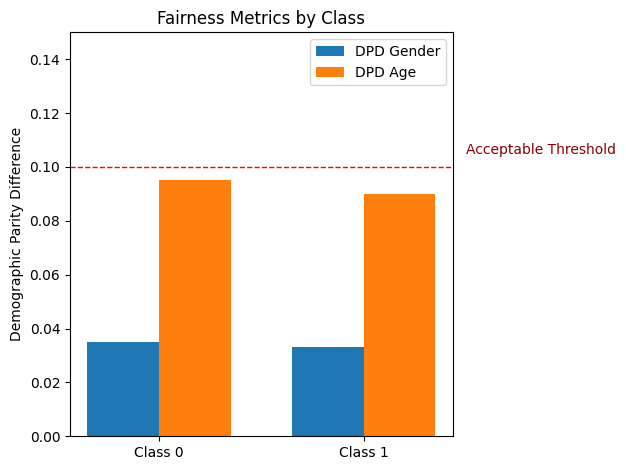

In [35]:
# Get protected attributes for test set
test_indices = X_test.index if hasattr(X_test, 'index') else range(len(X_test))
protected_test = protected_features.loc[test_indices]

# Run evaluation
evaluate_fairness(model, test_loader, protected_test)